# Analysis of LULC, Forest density, and Climate classification by cluster

In [1]:
import sys
import os
import platform
import importlib
import pandas as pd
import math
import glob
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import multiprocessing as mp
import calendar
import netCDF4 as nc
import xarray as xr
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta
from scipy.interpolate import griddata
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pyproj import Proj, transform
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as colors
import matplotlib.path as mpath
import rioxarray
import rasterio


if platform.system() == 'Darwin':  # macOS
    base_FP = '/home/nayoung/data'
    #base_FP = '/Users/kwonnayoung/data'
    cpuserver_data_FP = '/home/nayoung/cpuserver_data'
    #cpuserver_data_FP = '/Users/kwonnayoung/cpuserver_data'
    nas_data_FP = '/home/nayoung/nas_data'
    data2_FP = '/home/nayoung/data_2'
else:
    base_FP = '/home/nayoung/data'
    #base_FP = '/Users/kwonnayoung/data'
    cpuserver_data_FP = '/home/nayoung/cpuserver_data'
    #cpuserver_data_FP = '/Users/kwonnayoung/cpuserver_data'
    nas_data_FP = '/home/nayoung/nas_data'
    data2_FP = '/home/nayoung/data_2'
sys.path.append(base_FP + '/python_modules')

#hydroAI libs
import HydroAI.Data as hData
import HydroAI.Plot as hPlot
import HydroAI.Grid as hGrid
import HydroAI.Land_Properties as hLP
importlib.reload(hData);
importlib.reload(hPlot);
importlib.reload(hGrid);
importlib.reload(hLP);

# Ignore runtime warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Create land mask using DEM
DEM_path = '/home/nayoung/nas_data/DEM'

if os.path.exists(DEM_path):
    print("DEM_path exists")
else:
    print("DEM_path does not exist")

Find_DEM_File = sorted(glob.glob(os.path.join(DEM_path, "*.nc")))

with nc.Dataset(Find_DEM_File[0]) as ds:
    elev = ds.variables['elev'][:]      # (lat, lon)
    lat  = ds.variables['lat'][:]       # (lat,)
    lon  = ds.variables['lon'][:]       # (lon,)

# Extract the pixels in the range of 60N~90N
lat_mask_idx = np.where(lat >= 60)[0]

# Cut the pixels in the range of 60N~90N
elev_np = elev.filled(np.nan)  # masked count 0이라도 안전하게
elev_60N = elev_np[lat_mask_idx, :]
lat_60N = lat[lat_mask_idx]
lon_60N = lon

land_mask_60N_base = np.isfinite(elev_60N).astype(np.uint8)  # 1=land, 0=ocean

DEM_path exists


### Function of plotting northpole

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import matplotlib.colors as colors
import cartopy.crs as ccrs
import cartopy.feature as cfeature

domain_lon, domain_lat = hGrid.generate_lon_lat_eqdgrid(0.25)

def plot_Northpole(domain_lon, domain_lat, data, label_title, cmap,
                   vmin=-1, vmax=1, vcenter=0, bounds=None, ticks=None, ticklabels=None):

    fig = plt.figure(figsize=(10, 10))
    ax = plt.axes(projection=ccrs.NorthPolarStereo(central_longitude=0))

    theta = np.linspace(0, 2*np.pi, 100)
    center, radius = [0.5, 0.5], 0.5
    verts = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * radius + center)
    ax.set_boundary(circle, transform=ax.transAxes)

    ax.set_extent([-180, 180, 60, 90], crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.OCEAN, facecolor='powderblue', zorder=0)
    ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', zorder=1)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=3)

    masked_data = np.ma.masked_invalid(data)

    cmap_obj = plt.get_cmap(cmap).copy()
    cmap_obj.set_bad(alpha=0)

    # 연속/불연속 norm 분기
    if bounds is None:
        if vcenter is None:
            norm = colors.Normalize(vmin=vmin, vmax=vmax)
        else:
            norm = colors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)

    else:
        # bounds 예: [-0.5, 0.5, 1.5, 2.5] (클래스가 0,1,2일 때)
        norm = colors.BoundaryNorm(bounds, ncolors=cmap_obj.N, clip=True)

    mesh = ax.pcolormesh(
        domain_lon, domain_lat, masked_data,
        transform=ccrs.PlateCarree(),
        cmap=cmap_obj,
        norm=norm,
        zorder=2,
        shading="auto"
    )

    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=1, color='gray', alpha=0.5, linestyle='--', zorder=4)

    # 불연속일 때는 colorbar에도 boundaries를 같이 넘기면 "계단형"이 확실해짐
    cbar = plt.colorbar(
        mesh, ax=ax, orientation='horizontal',
        pad=0.05, shrink=0.8, extend='neither',
        boundaries=bounds if bounds is not None else None,
        ticks=ticks
    )
    cbar.set_label(label_title, fontsize=12, labelpad=10)

    if ticklabels is not None:
        cbar.set_ticklabels(ticklabels)
    elif bounds is None:
        tick_values = np.linspace(vmin, vmax, 5)
        cbar.set_ticks(tick_values)
        cbar.set_ticklabels([f'{v:.2f}' for v in tick_values])

    plt.title(label_title, fontsize=16, pad=20)
    plt.show()

    return fig, ax


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import matplotlib.colors as colors
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature

def plot_Northpole_OnlyForLULC(domain_lon, domain_lat, data, label_title, cmap,
                   vmin=-1, vmax=1, vcenter=0, bounds=None, ticks=None, ticklabels=None,
                   legend=False, legend_ncol=4, legend_bbox=(0.5, -0.08), legend_fontsize=10):

    fig = plt.figure(figsize=(10, 10))
    ax = plt.axes(projection=ccrs.NorthPolarStereo(central_longitude=0))

    theta = np.linspace(0, 2*np.pi, 100)
    center, radius = [0.5, 0.5], 0.5
    verts = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * radius + center)
    ax.set_boundary(circle, transform=ax.transAxes)

    ax.set_extent([-180, 180, 60, 90], crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.OCEAN, facecolor='powderblue', zorder=0)
    ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', zorder=1)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=3)

    masked_data = np.ma.masked_invalid(data)

    # cmap could be str or Colormap
    if isinstance(cmap, str):
        cmap_obj = plt.get_cmap(cmap).copy()
    else:
        cmap_obj = cmap
        try:
            cmap_obj = cmap_obj.copy()
        except Exception:
            pass

    cmap_obj.set_bad(alpha=0)

    # 연속/불연속 norm 분기
    if bounds is None:
        if vcenter is None:
            norm = colors.Normalize(vmin=vmin, vmax=vmax)
        else:
            norm = colors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)
    else:
        norm = colors.BoundaryNorm(bounds, ncolors=cmap_obj.N, clip=True)

    mesh = ax.pcolormesh(
        domain_lon, domain_lat, masked_data,
        transform=ccrs.PlateCarree(),
        cmap=cmap_obj,
        norm=norm,
        zorder=2,
        shading="auto"
    )

    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=1, color='gray', alpha=0.5, linestyle='--', zorder=4)

    # -------------------------
    # Legend mode (categorical)
    # -------------------------
    if legend:
        # ticks / ticklabels 없으면 자동 생성 (bounds 기반)
        if ticks is None and bounds is not None:
            ticks = np.arange(len(bounds) - 1)

        if ticklabels is None and ticks is not None:
            ticklabels = [str(t) for t in ticks]

        handles = []
        if ticks is not None and ticklabels is not None:
            # mesh에 실제 적용된 norm/cmap으로 색을 뽑아서 legend에 사용
            for t, lab in zip(ticks, ticklabels):
                rgba = mesh.cmap(mesh.norm(t))
                handles.append(mpatches.Patch(facecolor=rgba, edgecolor="none", label=lab))

        ax.legend(
            handles=handles,
            loc="center left",
            bbox_to_anchor=(1.02, 0.18),  
            ncol=1,
            fontsize=legend_fontsize,
            frameon=False
        )

    # -------------------------
    # Colorbar mode (default)
    # -------------------------
    else:
        cbar = plt.colorbar(
            mesh, ax=ax, orientation='horizontal',
            pad=0.05, shrink=0.8, extend='neither',
            boundaries=bounds if bounds is not None else None,
            ticks=ticks
        )
        cbar.set_label(label_title, fontsize=12, labelpad=10)

        if ticklabels is not None:
            cbar.set_ticklabels(ticklabels)
        elif bounds is None:
            tick_values = np.linspace(vmin, vmax, 5)
            cbar.set_ticks(tick_values)
            cbar.set_ticklabels([f'{v:.2f}' for v in tick_values])

    plt.title(label_title, fontsize=16, pad=20)
    plt.show()

    return fig, ax

### 1. Forest Density

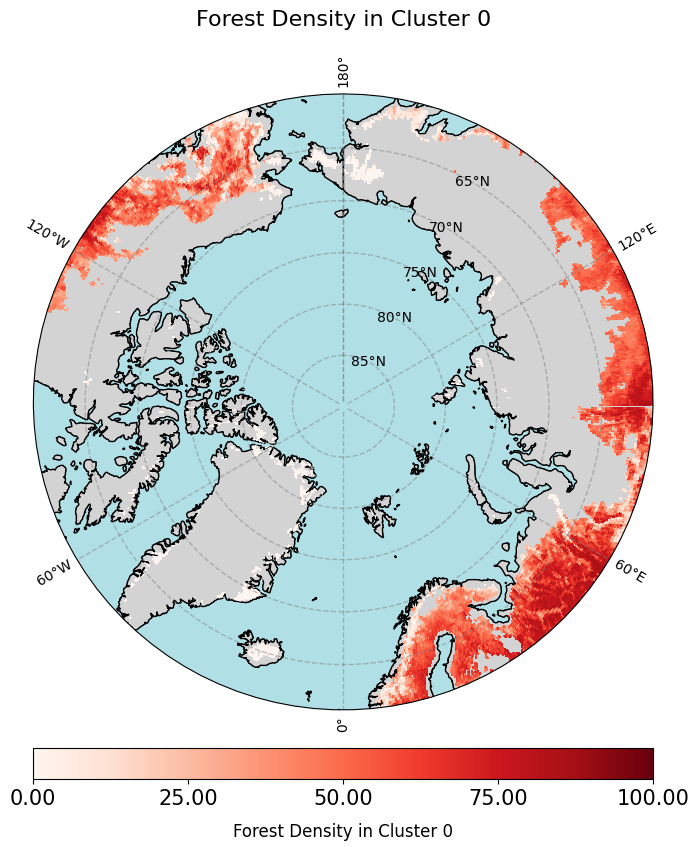

Mean Forest Density in Cluster 0:  44.12005


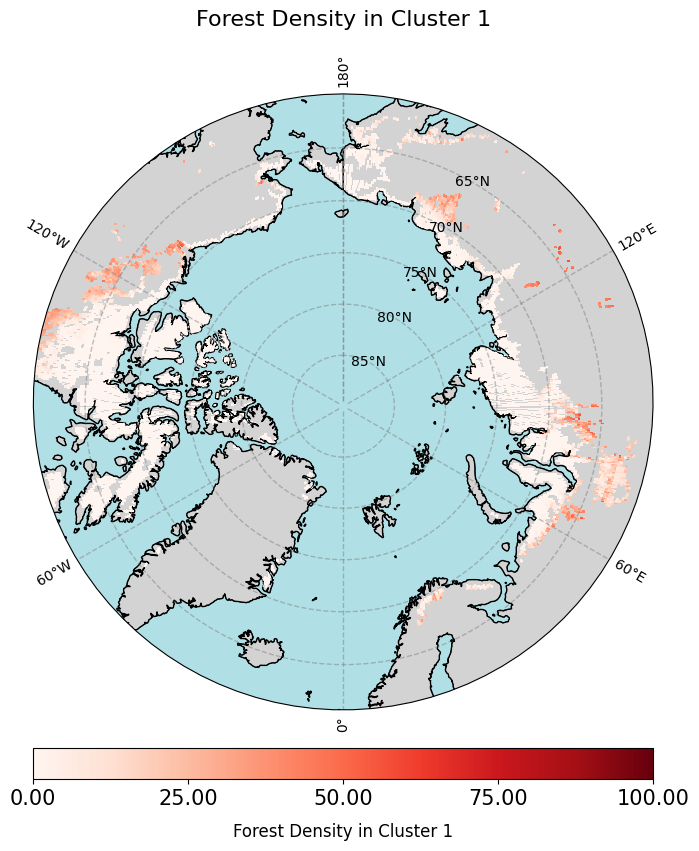

Mean Forest Density in Cluster 1:  4.500608


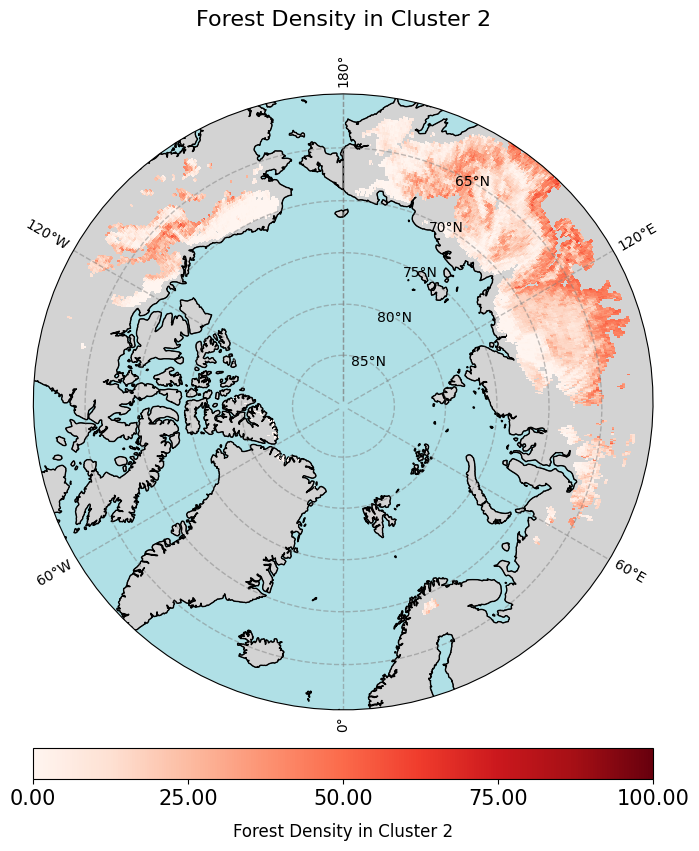

Mean Forest Density in Cluster 2:  16.370832


In [5]:
# Designate the paths
cluster_path = f"{cpuserver_data_FP}/personal_data/project_snow/MOD/New_TB_cluster_map.nc"
with nc.Dataset(cluster_path) as ds:
    lat_vals = ds.variables['lat'][:]
    lon_vals = ds.variables['lon'][:]
    TB_cluster = ds.variables['TB_cluster'][:] # (lat, lon)

Forest_density_path = f"{cpuserver_data_FP}/personal_data/project_snow/PFT_fraction/CDO_output/ForestDensity_1992_2020_60N.nc"
with nc.Dataset(Forest_density_path) as ds_forest:
    lat_vals = ds_forest.variables['lat'][:]
    lon_vals = ds_forest.variables['lon'][:]
    Forest_density = ds_forest.variables['forest_density'][:] # (time, lat, lon) = (29, 120, 1440) (time = 1992~2020)
    Forest_density_mean = ds_forest.variables['forest_density_mean'][:] # (lat, lon)

# Overlay the Forest density and TB cluster
Cluster0_forest_density = np.where(TB_cluster == 0, Forest_density_mean, np.nan)
Cluster1_forest_density = np.where(TB_cluster == 1, Forest_density_mean, np.nan)
Cluster2_forest_density = np.where(TB_cluster == 2, Forest_density_mean, np.nan)

# Plot the Forest density
for i in range(3):
    if i == 0:
        plot_Northpole(lon_vals, lat_vals, Cluster0_forest_density, "Forest Density in Cluster 0", "Reds", vmin=0, vmax=100, vcenter=50)
        print("Mean Forest Density in Cluster 0: ", np.nanmean(Cluster0_forest_density))
    elif i == 1:
        plot_Northpole(lon_vals, lat_vals, Cluster1_forest_density, "Forest Density in Cluster 1", "Reds", vmin=0, vmax=100, vcenter=50)
        print("Mean Forest Density in Cluster 1: ", np.nanmean(Cluster1_forest_density))
    elif i == 2:
        plot_Northpole(lon_vals, lat_vals, Cluster2_forest_density, "Forest Density in Cluster 2", "Reds", vmin=0, vmax=100, vcenter=50)
        print("Mean Forest Density in Cluster 2: ", np.nanmean(Cluster2_forest_density))




In [6]:
def area_weighted_nanmean(field_2d, lat_1d):
    """
    field_2d: (lat, lon) with NaNs
    lat_1d  : (lat,)
    """
    w = np.cos(np.deg2rad(lat_1d))[:, None]          # (lat, 1)
    valid = np.isfinite(field_2d)
    num = np.nansum(field_2d * w * valid)
    den = np.nansum(w * valid)
    return num / den if den > 0 else np.nan

for cid in [0, 1, 2]:
    masked = np.where(TB_cluster == cid, Forest_density_mean, np.nan)
    print(f"Pixel mean forest density in cluster {cid}: {np.nanmean(masked):.3f}")
    print(f"Area-weighted mean forest density in cluster {cid}: {area_weighted_nanmean(masked, lat_vals):.3f}")

Pixel mean forest density in cluster 0: 44.120
Area-weighted mean forest density in cluster 0: 46.028
Pixel mean forest density in cluster 1: 4.501
Area-weighted mean forest density in cluster 1: 5.232
Pixel mean forest density in cluster 2: 16.371
Area-weighted mean forest density in cluster 2: 17.071


### 2. LULC

In [7]:
import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt

# -----------------------------
# 0) Helper: build bounds from classes (midpoints)
# -----------------------------
def build_discrete_bounds_from_classes(classes, pad=0.5):
    """
    classes: 1D sorted unique class values (float or int)
    returns bounds for BoundaryNorm-style discrete color bins
    """
    classes = np.array(classes, dtype=float)
    classes = np.sort(classes)
    if len(classes) == 1:
        return np.array([classes[0] - pad, classes[0] + pad], dtype=float)

    mid = (classes[:-1] + classes[1:]) / 2.0
    bounds = np.concatenate(([classes[0] - pad], mid, [classes[-1] + pad]))
    return bounds


# -----------------------------
# 1) Helper: apply masking & (optional) grouping
# -----------------------------
def prepare_lulc_map(lulc_2d, mask_classes=(210, 220), group_map=None):
    """
    lulc_2d: (lat, lon) categorical (float/int)
    mask_classes: classes to set as NaN (e.g., water=210, snow/ice=220)
    group_map: dict like {10:0, 11:0, ...} to aggregate classes; if None, keep original classes
    """
    out = lulc_2d.astype(float).copy()

    # mask unwanted classes (water/snow)
    if mask_classes is not None and len(mask_classes) > 0:
        out[np.isin(out, list(mask_classes))] = np.nan

    # optional grouping
    if group_map is not None:
        grouped = np.full_like(out, np.nan, dtype=float)
        # robust int matching (in case stored as float)
        out_int = np.round(out).astype("float")  # keep nan
        for k, v in group_map.items():
            grouped[out_int == float(k)] = float(v)
        out = grouped

    return out


# -----------------------------
# 2) Helper: plot categorical LULC using your plot_Northpole
# -----------------------------
def plot_lulc_categorical(domain_lon, domain_lat, lulc_2d, title,
                          cmap_name="Set3",
                          ticks=None, ticklabels=None):
    """
    domain_lon/domain_lat can be 1D or 2D depending on your plot_Northpole usage.
    lulc_2d should already be masked/grouped as needed.
    """
    valid = np.isfinite(lulc_2d)
    classes = np.unique(lulc_2d[valid]).astype(float)
    classes = np.sort(classes)

    bounds = build_discrete_bounds_from_classes(classes, pad=0.5)

    K = len(classes)
    cmap_obj = plt.get_cmap(cmap_name, K)

    # default ticks/labels = class values
    if ticks is None:
        ticks = classes
    if ticklabels is None:
        ticklabels = [str(int(c)) for c in ticks]

    plot_Northpole(
        domain_lon, domain_lat,
        lulc_2d,
        title,
        cmap_obj,
        bounds=bounds,
        ticks=ticks,
        ticklabels=ticklabels
    )

    return classes


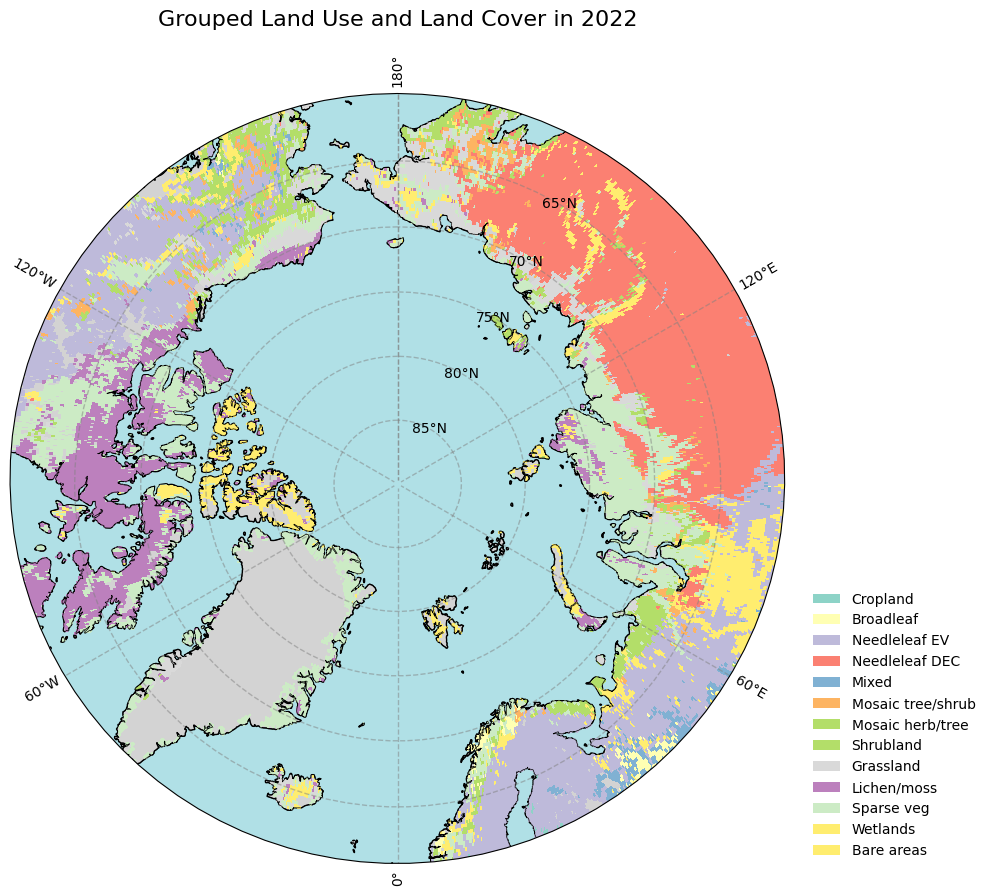

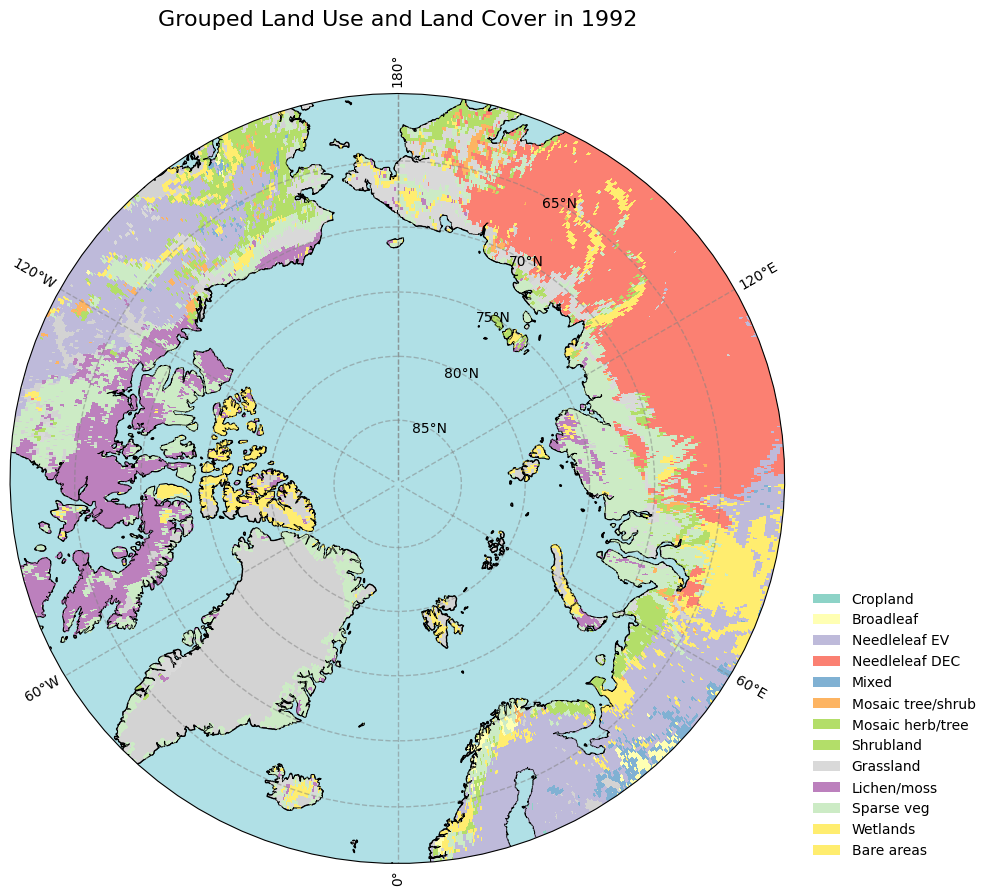

(<Figure size 1000x1000 with 1 Axes>,
 <GeoAxes: title={'center': 'Grouped Land Use and Land Cover in 1992'}>)

In [8]:
# -----------------------------
# 3) Main: load once and plot 1992 & 2022 consistently
# -----------------------------
LULC_path = f"{nas_data_FP}/LULC/ESA_CCI/Above_60N_Resampled_25km/ESA_CCI_LULC_25km_60N_1992_2022.nc"

with nc.Dataset(LULC_path) as ds:
    lat_vals = ds.variables["lat"][:]
    lon_vals = ds.variables["lon"][:]
    LULC = ds.variables["lccs_class"][:]  # (lat, lon, time)
    LULC_1992 = LULC[:, :, 0]
    LULC_2022 = LULC[:, :, -1]

# (선택) lon/lat 2D가 필요하면:
# lon2d, lat2d = np.meshgrid(lon_vals, lat_vals)
# 그리고 plot_Northpole에 lon2d, lat2d 넣기 (네 함수가 2D를 기대하면 이걸 추천)

# -----------------------------
# 4) Option A: 원래 class 그대로 플롯 (water/snow만 마스크)
# -----------------------------
lulc_2022_masked = prepare_lulc_map(LULC_2022, mask_classes=(210, 220), group_map=None)
lulc_1992_masked = prepare_lulc_map(LULC_1992, mask_classes=(210, 220), group_map=None)
'''
classes_2022 = plot_lulc_categorical(
    lon_vals, lat_vals,  # 또는 lon2d, lat2d
    lulc_2022_masked,
    "ESA-CCI Land Use and Land Cover in 2022 (class, masked 210/220)",
    cmap_name="tab20"
)
print("2022 classes (masked):", classes_2022)

classes_1992 = plot_lulc_categorical(
    lon_vals, lat_vals,  # 또는 lon2d, lat2d
    lulc_1992_masked,
    "ESA-CCI Land Use and Land Cover in 1992 (class, masked 210/220)",
    cmap_name="tab20"
)
print("1992 classes (masked):", classes_1992)
'''

# -----------------------------
# 5) Option B: 그룹핑해서 플롯 (네가 준 그룹 맵 사용)
# -----------------------------
CCI2A_GROUP = {
    10:0, 11:0,         # Cropland
    60:1, 61:1,         # Broadleaf
    70:2, 71:2,         # Needleleaf evergreen
    80:3,               # Needleleaf deciduous
    90:4,               # Mixed
    100:5,              # Mosaic tree/shrub
    110:6,              # Mosaic herb/tree
    120:7, 122:7,       # Shrubland
    130:8,              # Grassland
    140:9,              # Lichens & mosses
    150:10,             # Sparse vegetation
    160:11, 180:11,     # Wetlands
    200:12, 201:12      # Bare areas
}

group_labels = [
    "Cropland",
    "Broadleaf",
    "Needleleaf EV",
    "Needleleaf DEC",
    "Mixed",
    "Mosaic tree/shrub",
    "Mosaic herb/tree",
    "Shrubland",
    "Grassland",
    "Lichen/moss",
    "Sparse veg",
    "Wetlands",
    "Bare areas"
]

lulc_2022_group = prepare_lulc_map(LULC_2022, mask_classes=(210, 220), group_map=CCI2A_GROUP)
lulc_1992_group = prepare_lulc_map(LULC_1992, mask_classes=(210, 220), group_map=CCI2A_GROUP)

# 그룹 ID는 0~12 연속이라 ticks 고정 가능 (두 연도 색/레전드 일관성 확보)
K = len(group_labels)  # 13
bounds = np.arange(-0.5, K + 0.5, 1)
ticks = np.arange(K)

plot_Northpole_OnlyForLULC(lon_vals, lat_vals, lulc_2022_group, "Grouped Land Use and Land Cover in 2022",
    cmap=plt.get_cmap("Set3", K),
    bounds=bounds,
    ticks=ticks,
    ticklabels=group_labels,
    legend=True,      
    legend_ncol=4
)

plot_Northpole_OnlyForLULC(lon_vals, lat_vals, lulc_1992_group, "Grouped Land Use and Land Cover in 1992",
    cmap=plt.get_cmap("Set3", K),
    bounds=bounds,
    ticks=ticks,
    ticklabels=group_labels,
    legend=True,      
    legend_ncol=4
)


Cluster 0 (pixel-based):
  Top category = Needleleaf EV (45.37%)
  Needleleaf EV      :  45.37%
  Needleleaf DEC     :  17.84%
  Sparse veg         :   9.36%
  Wetlands           :   5.92%
  Shrubland          :   5.66%
  Mixed              :   4.33%
  Bare areas         :   4.33%
  Grassland          :   2.13%
  Mosaic tree/shrub  :   1.91%
  Broadleaf          :   1.83%
  Mosaic herb/tree   :   0.62%
  Lichen/moss        :   0.57%
  Cropland           :   0.13%

Cluster 1 (pixel-based):
  Top category = Sparse veg (36.03%)
  Sparse veg         :  36.03%
  Lichen/moss        :  25.60%
  Bare areas         :   8.18%
  Grassland          :   6.72%
  Needleleaf EV      :   5.63%
  Needleleaf DEC     :   5.52%
  Shrubland          :   5.44%
  Wetlands           :   4.37%
  Mosaic tree/shrub  :   2.11%
  Mosaic herb/tree   :   0.21%
  Broadleaf          :   0.17%
  Mixed              :   0.02%

Cluster 2 (pixel-based):
  Top category = Needleleaf DEC (56.60%)
  Needleleaf DEC     :  56.60

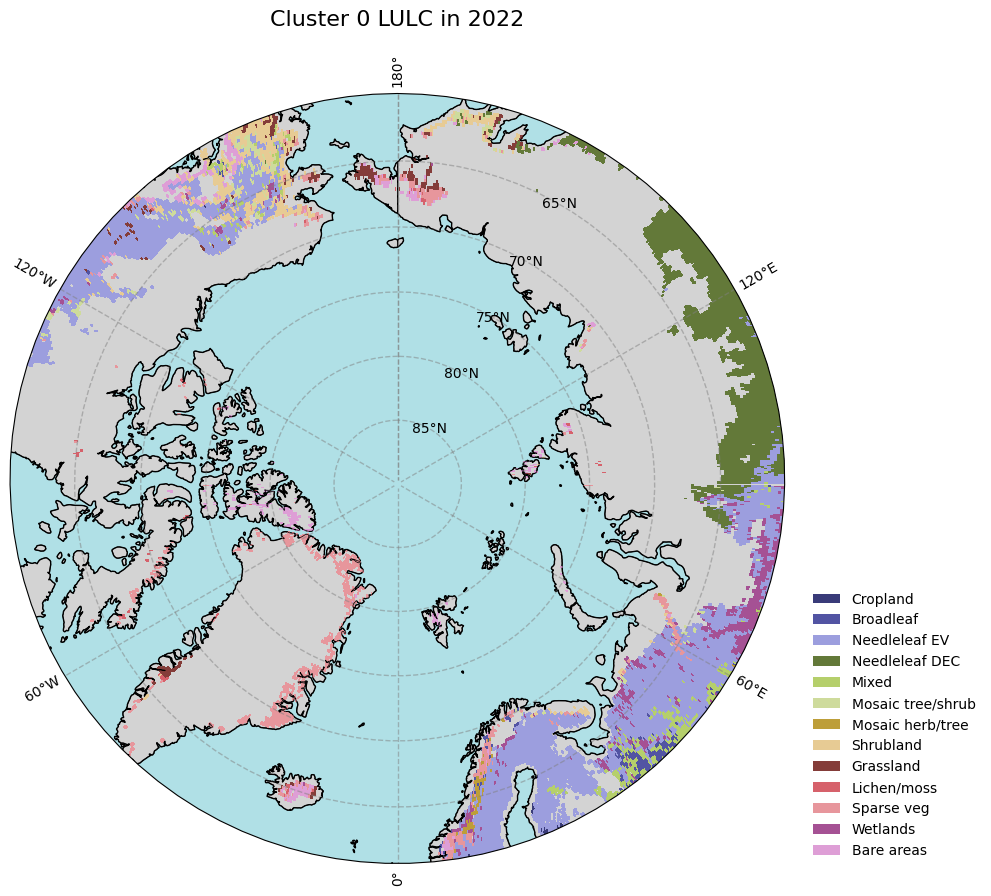

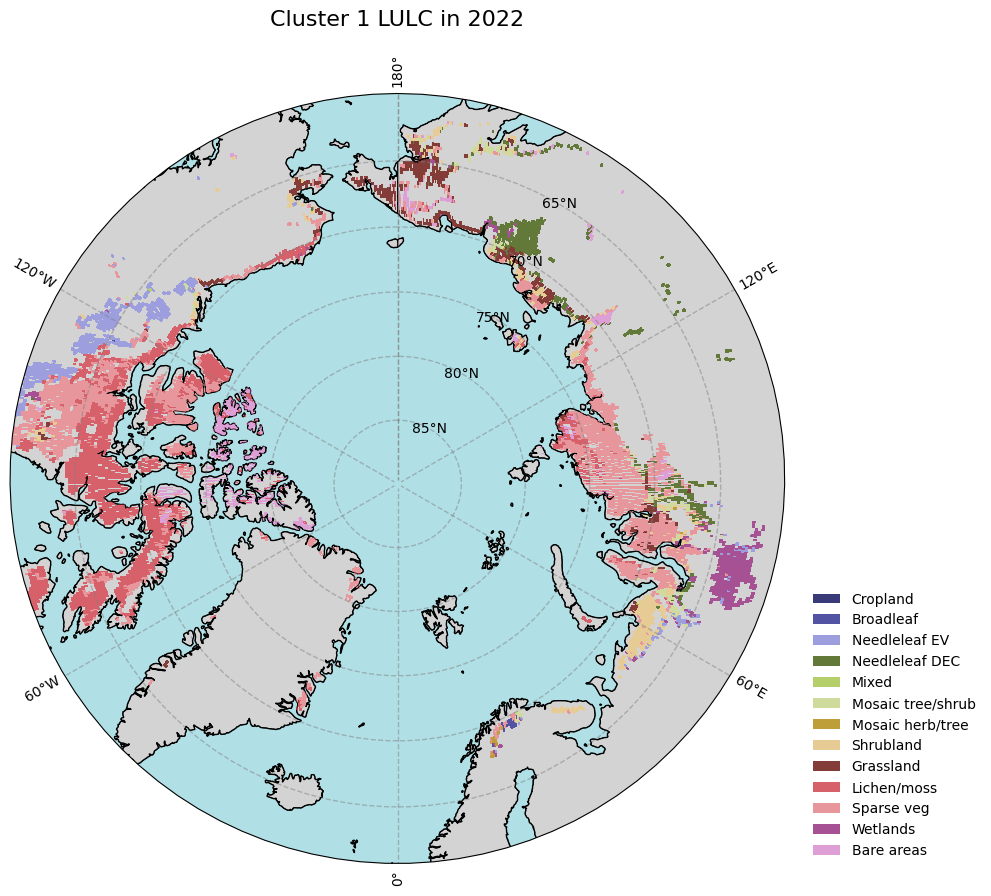

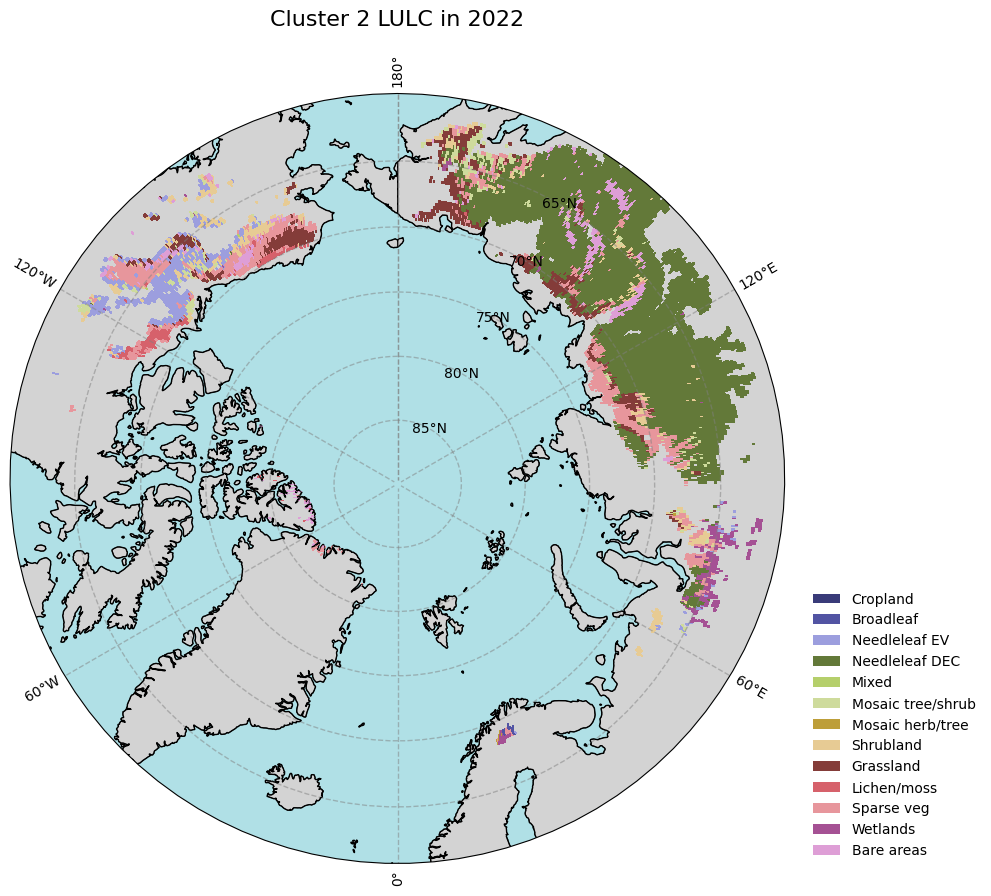

In [9]:
import numpy as np

def cluster_lulc_fraction_pixel(TB_cluster, lulc_group, group_labels, cluster_ids=(0,1,2)):
    """
    Returns dict: {cid: {group_id: fraction(0-1), ...}, ...}
    Pixel-count based (NOT area-weighted).
    """
    out = {}
    for cid in cluster_ids:
        m = (TB_cluster == cid) & np.isfinite(lulc_group)
        vals = lulc_group[m].astype(int)

        if vals.size == 0:
            out[cid] = {}
            continue

        counts = np.bincount(vals, minlength=len(group_labels))
        frac = counts / counts.sum()

        out[cid] = {gid: frac[gid] for gid in range(len(group_labels))}
    return out


frac_pix = cluster_lulc_fraction_pixel(TB_cluster, lulc_2022_group, group_labels, cluster_ids=(0,1,2))

for cid in [0,1,2]:
    fr = frac_pix.get(cid, {})
    if not fr:
        print(f"Cluster {cid}: no valid pixels")
        continue

    # top category
    top_gid = max(fr, key=fr.get)
    print(f"\nCluster {cid} (pixel-based):")
    print(f"  Top category = {group_labels[top_gid]} ({fr[top_gid]*100:.2f}%)")

    # print all categories sorted
    for gid, f in sorted(fr.items(), key=lambda x: x[1], reverse=True):
        if f > 0:
            print(f"  {group_labels[gid]:<18s} : {f*100:6.2f}%")



for cid in [0,1,2]:
    masked = np.where(TB_cluster == cid, lulc_2022_group, np.nan)
    plot_Northpole_OnlyForLULC(lon_vals, lat_vals, masked, f"Cluster {cid} LULC in 2022", "tab20b", bounds=bounds, ticks=ticks, ticklabels=group_labels, legend=True, legend_ncol=4)

### 3. Annual SWE

In [10]:
def is_leap_year(year):
    return year % 4 == 0 and (year % 100 != 0 or year % 400 == 0)

def days_in_year(year):
    return 366 if is_leap_year(year) else 365


In [11]:
start_year, end_year = 1988, 2022

# Designate the paths
Daily_ERA5_path = f"{data2_FP}/ERA5_Land/extracted_nc/Above_60N/Revised_ERA5_25km_60N"
TB_cluster_path = f"{cpuserver_data_FP}/personal_data/project_snow/MOD/New_TB_cluster_map.nc"

# Cluster-specific peak SWE / snow depth storage
peak_SWE_storage_cluster0 = []
peak_Snow_depth_storage_cluster0 = []
peak_SWE_storage_cluster1 = []
peak_Snow_depth_storage_cluster1 = []
peak_SWE_storage_cluster2 = []
peak_Snow_depth_storage_cluster2 = []

# Load the data
with nc.Dataset(TB_cluster_path) as ds:
    lat_vals = ds.variables['lat'][:]
    lon_vals = ds.variables['lon'][:]
    TB_cluster = ds.variables['TB_cluster'][:] # (lat, lon)

for year in range(start_year, end_year+1):
    ERA5_SWE_path = f"{Daily_ERA5_path}/ERA5_Land_Daily_Above_60N_{year}.nc"
    with nc.Dataset(ERA5_SWE_path) as ds:
        SWE = ds.variables['sd_mean'][:]       # (lat, lon, time)
        Snow_depth = ds.variables['sde_mean'][:]  # (lat, lon, time)

        peak_SWE        = np.max(SWE[:, :, :250], axis=2)         # (lat, lon)
        peak_Snow_depth = np.max(Snow_depth[:, :, :250], axis=2)  # (lat, lon)

        for cid in [0, 1, 2]:
            m = (TB_cluster == cid)
            mean_peak_swe = np.nanmean(peak_SWE[m])
            mean_peak_sd  = np.nanmean(peak_Snow_depth[m])

            if cid == 0:
                peak_SWE_storage_cluster0.append(mean_peak_swe)
                peak_Snow_depth_storage_cluster0.append(mean_peak_sd)
            elif cid == 1:
                peak_SWE_storage_cluster1.append(mean_peak_swe)
                peak_Snow_depth_storage_cluster1.append(mean_peak_sd)
            elif cid == 2:
                peak_SWE_storage_cluster2.append(mean_peak_swe)
                peak_Snow_depth_storage_cluster2.append(mean_peak_sd)

# Yearly mean SWE / snow depth per cluster
Cluster0_peak_SWE_mean = np.nanmean(peak_SWE_storage_cluster0)
Cluster0_peak_Snow_depth_mean = np.nanmean(peak_Snow_depth_storage_cluster0)
Cluster1_peak_SWE_mean = np.nanmean(peak_SWE_storage_cluster1)
Cluster1_peak_Snow_depth_mean = np.nanmean(peak_Snow_depth_storage_cluster1)
Cluster2_peak_SWE_mean = np.nanmean(peak_SWE_storage_cluster2)
Cluster2_peak_Snow_depth_mean = np.nanmean(peak_Snow_depth_storage_cluster2)

print("Peak SWE mean per cluster:")
print(Cluster0_peak_SWE_mean)
print(Cluster1_peak_SWE_mean)
print(Cluster2_peak_SWE_mean)

print("Peak Snow depth mean per cluster:")
print(Cluster0_peak_Snow_depth_mean)
print(Cluster1_peak_Snow_depth_mean)
print(Cluster2_peak_Snow_depth_mean)


Peak SWE mean per cluster:
0.8101067
0.4200084
0.19650304
Peak Snow depth mean per cluster:
2.8533003
1.6284603
0.90549636


=== Seasonal-mask impact (per cluster) ===
Cluster 0: base pixels = 14288
  kept pixels (mean ± std over years): 13045 ± 23
  kept fraction (mean ± std): 91.3% ± 0.2%
  union seasonal fraction (any year): 91.5%
Cluster 1: base pixels = 11975
  kept pixels (mean ± std over years): 11290 ± 31
  kept fraction (mean ± std): 94.3% ± 0.3%
  union seasonal fraction (any year): 94.4%
Cluster 2: base pixels = 13848
  kept pixels (mean ± std over years): 13675 ± 47
  kept fraction (mean ± std): 98.8% ± 0.3%
  union seasonal fraction (any year): 98.9%

=== Peak DOY from 35-year mean climatology ===

Cluster 0
  SWE  peak: DOY 95, value = 0.1829
  SD   peak: DOY 60, value = 0.7318
  Snow cover peak: DOY 46, value = 97.7778
  SWE  zero: DOY 213, value = 0.0000
  SD   zero: DOY 207, value = 0.0001
  Snow cover zero: DOY 207, value = 0.0989

Cluster 1
  SWE  peak: DOY 117, value = 0.1553
  SD   peak: DOY 75, value = 0.7346
  Snow cover peak: DOY 66, value = 97.2280
  SWE  zero: DOY 208, value = 0.000

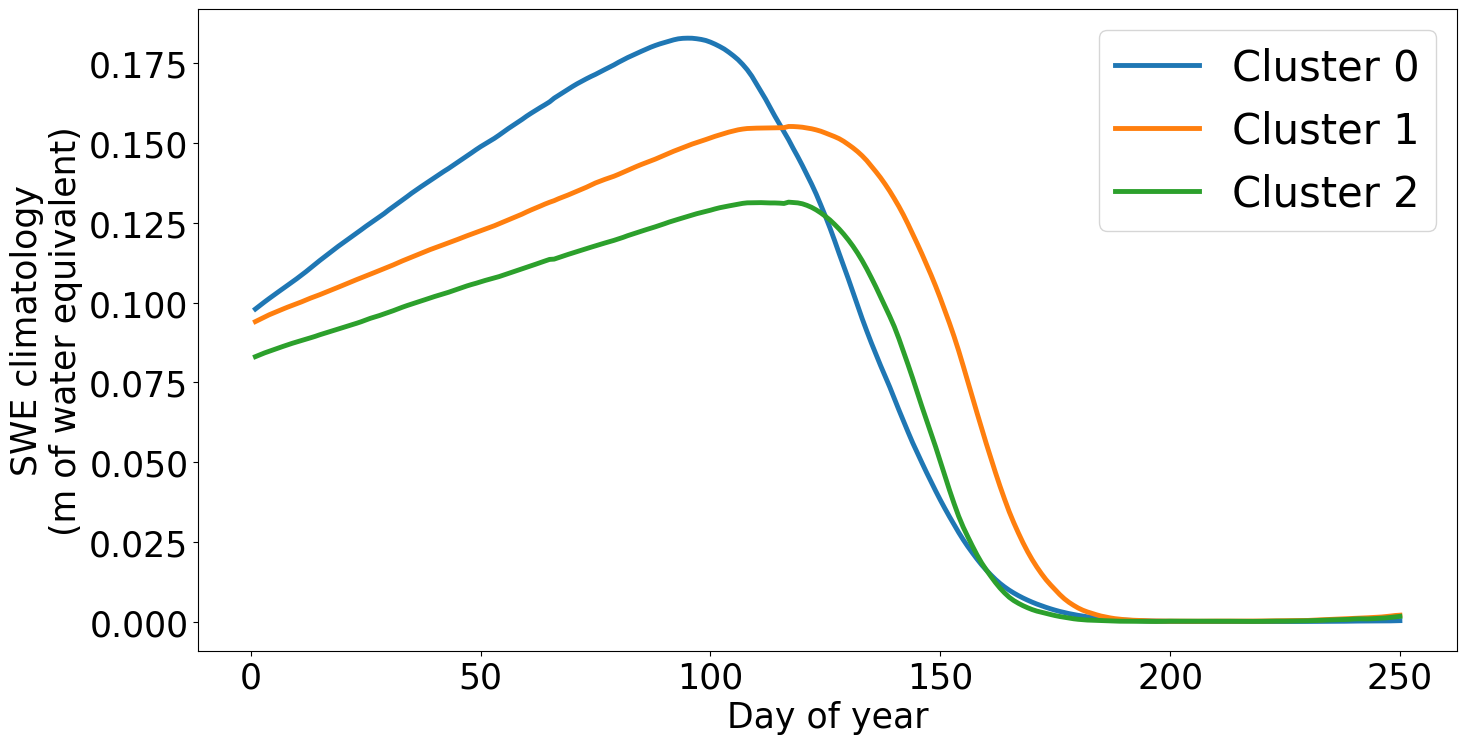

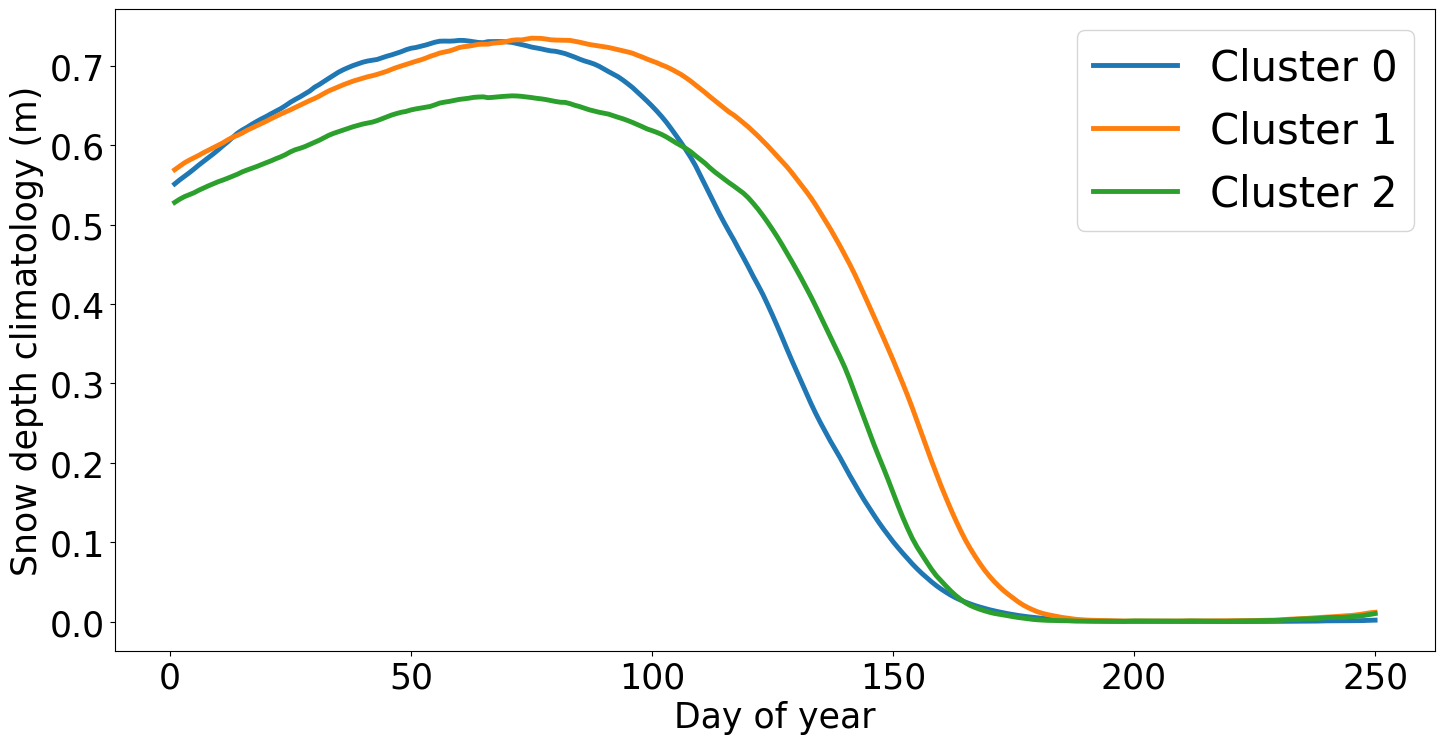

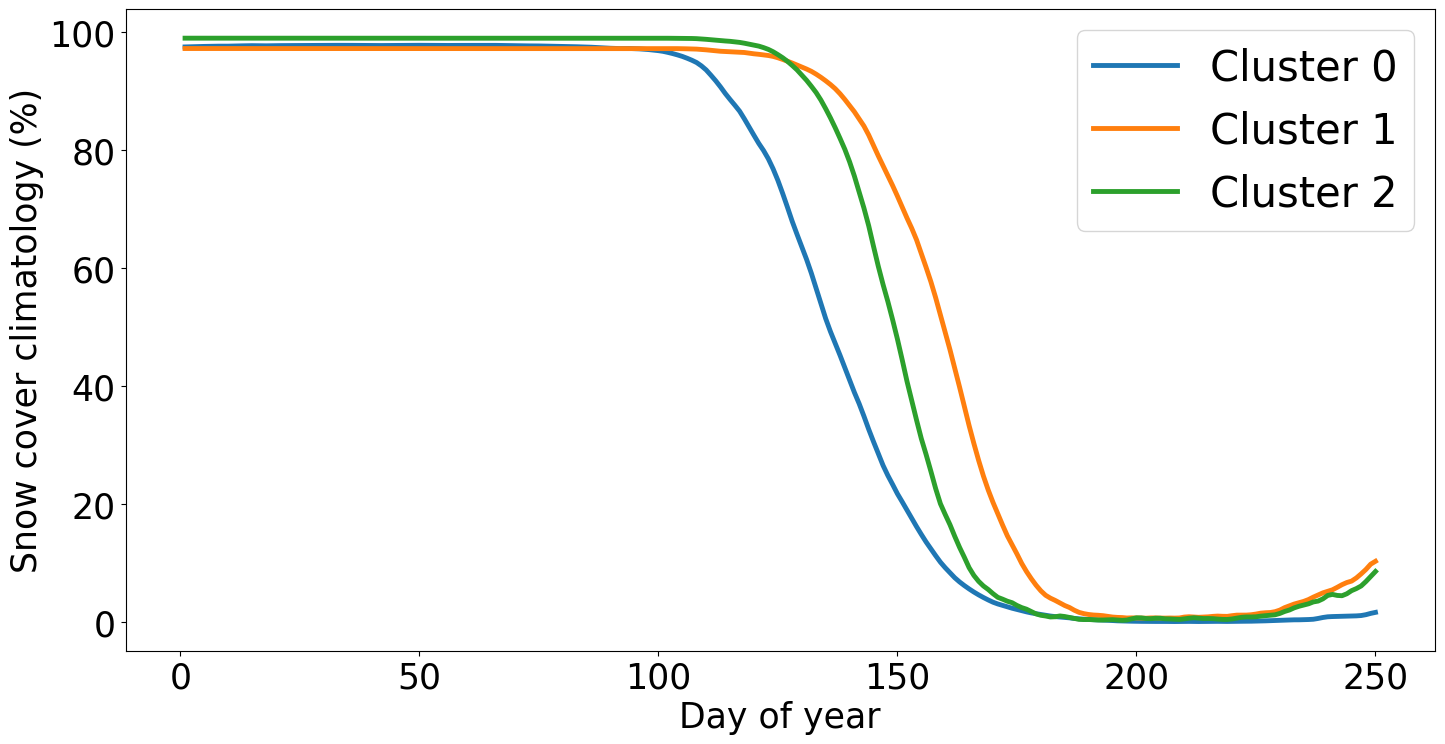

In [12]:
import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt

out_dir = "/home/nayoung/cpuserver_data/python_modules/Nayoung/Accurate_MOD_estimation/DPI300_Figures"


start_year, end_year = 1988, 2022
years = np.arange(start_year, end_year + 1)
ndoy = 250

Daily_ERA5_path = f"{data2_FP}/ERA5_Land/extracted_nc/Above_60N/Revised_ERA5_25km_60N"
TB_cluster_path = f"{cpuserver_data_FP}/personal_data/project_snow/MOD/New_TB_cluster_map.nc"

# ----------------------------
# 1) Load cluster map
# ----------------------------
with nc.Dataset(TB_cluster_path) as ds:
    TB_cluster = ds.variables["TB_cluster"][:]
TB_cluster = TB_cluster.astype(int)

cluster_ids = [0, 1, 2]
base_counts = {cid: int(np.sum(TB_cluster == cid)) for cid in cluster_ids}

# ----------------------------
# 2) Storage
# ----------------------------
# (year, doy) climatology storage
clim_swe = {cid: np.full((len(years), ndoy), np.nan, np.float32) for cid in cluster_ids}
clim_sd  = {cid: np.full((len(years), ndoy), np.nan, np.float32) for cid in cluster_ids}
clim_snowcover = {cid: np.full((len(years), ndoy), np.nan, np.float32) for cid in cluster_ids}

# Diagnostics: per-year kept pixel counts and fractions (after seasonal_mask)
mask_counts = {cid: [] for cid in cluster_ids}
mask_fracs  = {cid: [] for cid in cluster_ids}

# Union seasonal mask (True if seasonal_mask True in ANY year)
seasonal_union = np.zeros_like(TB_cluster, dtype=bool)

# Precompute cluster masks
cluster_masks = {cid: (TB_cluster == cid) for cid in cluster_ids}

# ----------------------------
# 3) Loop over years
# ----------------------------
for yi, year in enumerate(years):
    path = f"{Daily_ERA5_path}/ERA5_Land_Daily_Above_60N_{year}.nc"
    with nc.Dataset(path) as ds:
        SWE = ds.variables["sd_mean"][:, :, :ndoy]   # SWE (m w.e.)  (lat, lon, doy)
        SD  = ds.variables["sde_mean"][:, :, :ndoy]  # snow depth (m) (lat, lon, doy)
        SnowCover = ds.variables["snowc_mean"][:, :, :ndoy] # snow cover (mm/day) (lat, lon, doy)

    # Seasonal snow mask: keep pixels with near-zero summer SWE
    # DOY 200–230 -> indices 199:230
    summer_mean_swe = np.nanmean(SWE[:, :, 199:230], axis=2)
    seasonal_mask = (summer_mean_swe < 0.01)  # 0.01 m w.e. = 10 mm

    # Update union mask
    seasonal_union |= seasonal_mask

    # Diagnostics: how many pixels kept per cluster in this year?
    for cid in cluster_ids:
        base = cluster_masks[cid]
        n_base = base_counts[cid]
        n_keep = int(np.sum(base & seasonal_mask))
        mask_counts[cid].append(n_keep)
        mask_fracs[cid].append(n_keep / n_base if n_base > 0 else np.nan)

    # Compute per-DOY spatial means within each cluster (with seasonal mask)
    for d in range(ndoy):
        swe_d = SWE[:, :, d]
        sd_d  = SD[:, :, d]
        snowcover_d = SnowCover[:, :, d]
        for cid in cluster_ids:
            m = cluster_masks[cid] & seasonal_mask
            if np.any(m):
                clim_swe[cid][yi, d] = np.nanmean(swe_d[m])
                clim_sd[cid][yi, d]  = np.nanmean(sd_d[m])
                clim_snowcover[cid][yi, d] = np.nanmean(snowcover_d[m])
            else:
                clim_swe[cid][yi, d] = np.nan
                clim_sd[cid][yi, d]  = np.nan
                clim_snowcover[cid][yi, d] = np.nan

# ----------------------------
# 4) Summaries
# ----------------------------
print("=== Seasonal-mask impact (per cluster) ===")
for cid in cluster_ids:
    print(f"Cluster {cid}: base pixels = {base_counts[cid]}")
    print(f"  kept pixels (mean ± std over years): "
          f"{np.mean(mask_counts[cid]):.0f} ± {np.std(mask_counts[cid]):.0f}")
    print(f"  kept fraction (mean ± std): "
          f"{np.mean(mask_fracs[cid])*100:.1f}% ± {np.std(mask_fracs[cid])*100:.1f}%")
    print(f"  union seasonal fraction (any year): "
          f"{np.mean(seasonal_union[cluster_masks[cid]])*100:.1f}%")


# 35-year mean climatologies
clim_swe_mean = {cid: np.nanmean(clim_swe[cid], axis=0) for cid in cluster_ids}
clim_sd_mean  = {cid: np.nanmean(clim_sd[cid], axis=0) for cid in cluster_ids}
clim_snowcover_mean = {cid: np.nanmean(clim_snowcover[cid], axis=0) for cid in cluster_ids}


# ----------------------------
# 4-1) Peak DOY and peak value
# ----------------------------
def get_peak_doy_and_value(arr):
    if np.all(np.isnan(arr)):
        return np.nan, np.nan
    peak_idx = np.nanargmax(arr)   # 0-based index
    peak_doy = peak_idx + 1        # convert to DOY
    peak_val = arr[peak_idx]
    return peak_doy, peak_val

def get_zero_doy_and_value(arr):
    if np.all(np.isnan(arr)):
        return np.nan, np.nan
    zero_idx = np.nanargmin(arr)   # 0-based index
    zero_doy = zero_idx + 1        # convert to DOY
    zero_val = arr[zero_idx]
    return zero_doy, zero_val

print("\n=== Peak DOY from 35-year mean climatology ===")
for cid in cluster_ids:
    swe_peak_doy, swe_peak_val = get_peak_doy_and_value(clim_swe_mean[cid])
    sd_peak_doy, sd_peak_val = get_peak_doy_and_value(clim_sd_mean[cid])
    snowcover_peak_doy, snowcover_peak_val = get_peak_doy_and_value(clim_snowcover_mean[cid])

    print(f"\nCluster {cid}")
    print(f"  SWE  peak: DOY {swe_peak_doy}, value = {swe_peak_val:.4f}")
    print(f"  SD   peak: DOY {sd_peak_doy}, value = {sd_peak_val:.4f}")
    print(f"  Snow cover peak: DOY {snowcover_peak_doy}, value = {snowcover_peak_val:.4f}")

    swe_zero_doy, swe_zero_val = get_zero_doy_and_value(clim_swe_mean[cid])
    sd_zero_doy, sd_zero_val = get_zero_doy_and_value(clim_sd_mean[cid])
    snowcover_zero_doy, snowcover_zero_val = get_zero_doy_and_value(clim_snowcover_mean[cid])

    print(f"  SWE  zero: DOY {swe_zero_doy}, value = {swe_zero_val:.4f}")
    print(f"  SD   zero: DOY {sd_zero_doy}, value = {sd_zero_val:.4f}")
    print(f"  Snow cover zero: DOY {snowcover_zero_doy}, value = {snowcover_zero_val:.4f}")

# ----------------------------
# 5) Plot
# ----------------------------
doys = np.arange(1, ndoy + 1)
plt.rcParams.update({
    'font.size': 25,        
    'axes.titlesize': 30,     
    'axes.labelsize': 25,     
    'xtick.labelsize': 25,   
    'ytick.labelsize': 25,    
    'legend.fontsize': 30     
})

plt.figure(figsize=(15, 8))
for cid in cluster_ids:
    plt.plot(doys, clim_swe_mean[cid], label=f"Cluster {cid}", linewidth=3.5)
plt.xlabel("Day of year")
plt.ylabel("SWE climatology\n(m of water equivalent)")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "SWE_climatology.png"),
            dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(15, 8))
for cid in cluster_ids:
    plt.plot(doys, clim_sd_mean[cid], label=f"Cluster {cid}", linewidth=3.5)
plt.xlabel("Day of year")
plt.ylabel("Snow depth climatology (m)")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "Snowdepth_climatology.png"),
            dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(15, 8))
for cid in cluster_ids:
    plt.plot(doys, clim_snowcover_mean[cid], label=f"Cluster {cid}", linewidth=3.5)
plt.xlabel("Day of year")
plt.ylabel("Snow cover climatology (%)")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "Snowcover_climatology.png"),
            dpi=300, bbox_inches="tight")
plt.show()

### 4. Annual Temperature

=== Seasonal-mask impact (per cluster) ===
Cluster 0: base pixels = 14288
  kept pixels (mean ± std over years): 13045 ± 23
  kept fraction (mean ± std): 91.3% ± 0.2%
  union seasonal fraction (any year): 91.5%
Cluster 1: base pixels = 11975
  kept pixels (mean ± std over years): 11290 ± 31
  kept fraction (mean ± std): 94.3% ± 0.3%
  union seasonal fraction (any year): 94.4%
Cluster 2: base pixels = 13848
  kept pixels (mean ± std over years): 13675 ± 47
  kept fraction (mean ± std): 98.8% ± 0.3%
  union seasonal fraction (any year): 98.9%


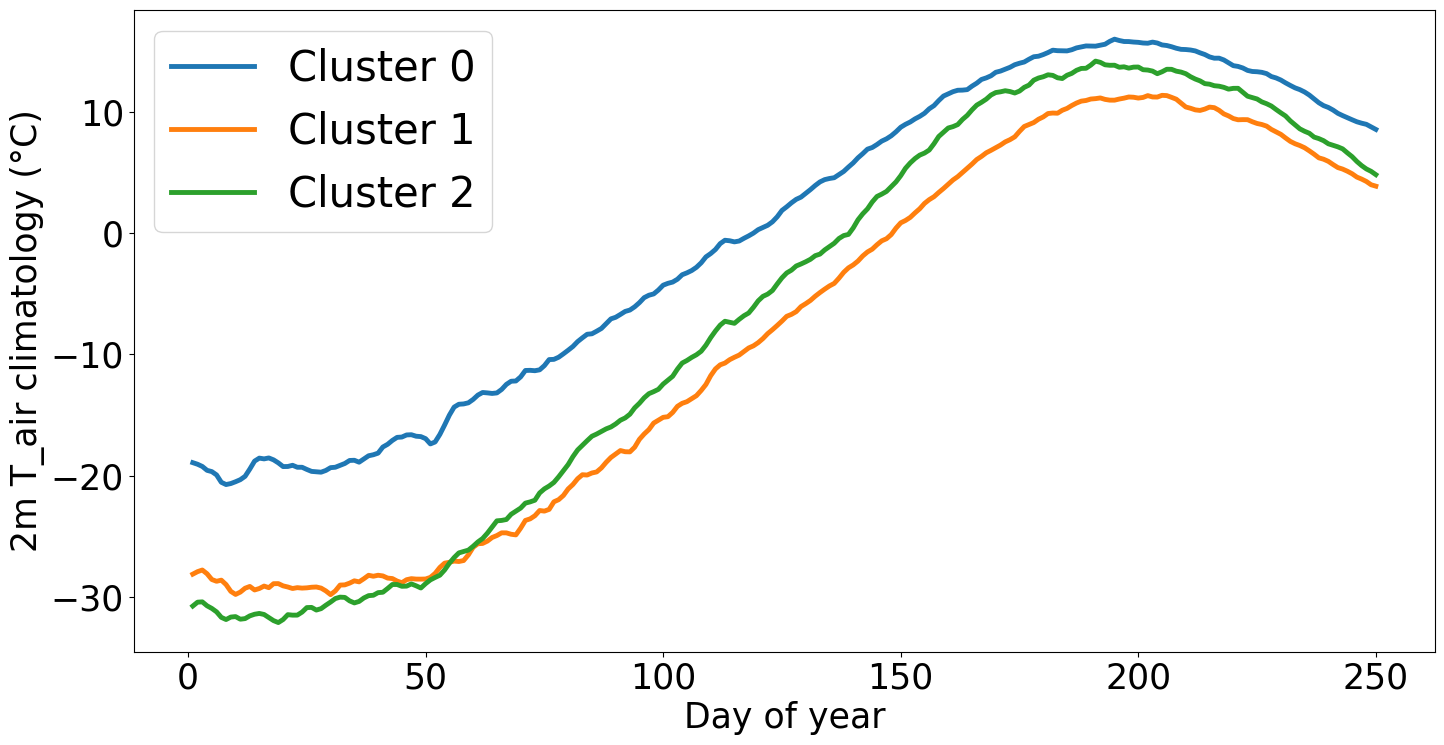

In [13]:
import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt

start_year, end_year = 1988, 2022
years = np.arange(start_year, end_year + 1)
ndoy = 250
out_dir = "/home/nayoung/cpuserver_data/python_modules/Nayoung/Accurate_MOD_estimation/DPI300_Figures"


Daily_ERA5_path = f"{data2_FP}/ERA5_Land/extracted_nc/Above_60N/Revised_ERA5_25km_60N"
TB_cluster_path = f"{cpuserver_data_FP}/personal_data/project_snow/MOD/New_TB_cluster_map.nc"

# ----------------------------
# 1) Load cluster map
# ----------------------------
with nc.Dataset(TB_cluster_path) as ds:
    TB_cluster = ds.variables["TB_cluster"][:]
TB_cluster = TB_cluster.astype(int)

cluster_ids = [0, 1, 2]
base_counts = {cid: int(np.sum(TB_cluster == cid)) for cid in cluster_ids}

# ----------------------------
# 2) Storage
# ----------------------------
# (year, doy) climatology storage for T_air (°C)
clim_tair = {cid: np.full((len(years), ndoy), np.nan, np.float32) for cid in cluster_ids}

# Diagnostics: per-year kept pixel counts and fractions (after seasonal_mask)
mask_counts = {cid: [] for cid in cluster_ids}
mask_fracs  = {cid: [] for cid in cluster_ids}

# Union seasonal mask (True if seasonal_mask True in ANY year)
seasonal_union = np.zeros_like(TB_cluster, dtype=bool)

# Precompute cluster masks
cluster_masks = {cid: (TB_cluster == cid) for cid in cluster_ids}

# ----------------------------
# 3) Loop over years
# ----------------------------
for yi, year in enumerate(years):
    path = f"{Daily_ERA5_path}/ERA5_Land_Daily_Above_60N_{year}.nc"
    with nc.Dataset(path) as ds:
        # SWE used ONLY for seasonal mask (keep same logic)
        SWE  = ds.variables["sd_mean"][:, :, :ndoy]    # SWE (m w.e.)  (lat, lon, doy)
        Tair = ds.variables["t2m_mean"][:, :, :ndoy]   # air temperature (K) (lat, lon, doy)

    # Seasonal snow mask: keep pixels with near-zero summer SWE
    # DOY 200–230 -> indices 199:230
    summer_mean_swe = np.nanmean(SWE[:, :, 199:230], axis=2)
    seasonal_mask = (summer_mean_swe < 0.01)  # 0.01 m w.e. = 10 mm

    # Update union mask
    seasonal_union |= seasonal_mask

    # Diagnostics: how many pixels kept per cluster in this year?
    for cid in cluster_ids:
        base = cluster_masks[cid]
        n_base = base_counts[cid]
        n_keep = int(np.sum(base & seasonal_mask))
        mask_counts[cid].append(n_keep)
        mask_fracs[cid].append(n_keep / n_base if n_base > 0 else np.nan)

    # Convert to °C once per year (float32 to save memory)
    Tair_C = (Tair.astype(np.float32) - 273.15)

    # Compute per-DOY spatial means within each cluster (with seasonal mask)
    for d in range(ndoy):
        t_d = Tair_C[:, :, d]
        for cid in cluster_ids:
            m = cluster_masks[cid] & seasonal_mask
            if np.any(m):
                clim_tair[cid][yi, d] = np.nanmean(t_d[m])
            else:
                clim_tair[cid][yi, d] = np.nan

# ----------------------------
# 4) Summaries
# ----------------------------
print("=== Seasonal-mask impact (per cluster) ===")
for cid in cluster_ids:
    print(f"Cluster {cid}: base pixels = {base_counts[cid]}")
    print(f"  kept pixels (mean ± std over years): "
          f"{np.mean(mask_counts[cid]):.0f} ± {np.std(mask_counts[cid]):.0f}")
    print(f"  kept fraction (mean ± std): "
          f"{np.mean(mask_fracs[cid])*100:.1f}% ± {np.std(mask_fracs[cid])*100:.1f}%")
    print(f"  union seasonal fraction (any year): "
          f"{np.mean(seasonal_union[cluster_masks[cid]])*100:.1f}%")

# 35-year mean climatologies (°C)
clim_tair_mean = {cid: np.nanmean(clim_tair[cid], axis=0) for cid in cluster_ids}

# ----------------------------
# 5) Plot
# ----------------------------
doys = np.arange(1, ndoy + 1)

plt.rcParams.update({
    'font.size': 25,        
    'axes.titlesize': 30,     
    'axes.labelsize': 25,     
    'xtick.labelsize': 25,   
    'ytick.labelsize': 25,    
    'legend.fontsize': 30     
})


plt.figure(figsize=(15, 8))
for cid in cluster_ids:
    plt.plot(doys, clim_tair_mean[cid], label=f"Cluster {cid}", linewidth=3.5)
plt.xlabel("Day of year")
plt.ylabel("2m T_air climatology (°C)")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "Tair_climatology.png"),
            dpi=300, bbox_inches="tight")
plt.show()